In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

# Example n6: 2D pin depletion

# 1. Materials

In [2]:
fuel = openmc.Material(name='UO2 fuel')
fuel.set_density('g/cm3', 10.5)
fuel.add_element('U', 1.0, enrichment=4.5)
fuel.add_element('O', 2.0)
fuel.volume = 3.14 * 0.39**2 # cm2

gap = openmc.Material(name='Helium gap')
gap.set_density('g/cm3', 0.001)
gap.add_element('He', 1.0)

clad = openmc.Material(name='Zircaloy')
clad.set_density('g/cm3', 6.55)
clad.add_element('Zr', 1.0)

water = openmc.Material(name='Water')
water.set_density('g/cm3', 0.75)
water.add_element('H', 2.0)
water.add_element('O', 1.0)
water.add_s_alpha_beta('c_H_in_H2O')

materials = openmc.Materials([fuel, gap, clad, water])
materials.export_to_xml()

# 2. Geometry

In [3]:
# Dimensions (cm)
r_fuel = 0.39 
r_gap = 0.40
r_clad = 0.475

# PITCH!
pitch = 1.26

# Cylinders
fuel_cyl = openmc.ZCylinder(r=r_fuel)
gap_cyl = openmc.ZCylinder(r=r_gap)
clad_cyl = openmc.ZCylinder(r=r_clad)

left = openmc.XPlane(x0=-pitch/2, boundary_type='reflective') 
right = openmc.XPlane(x0=+pitch/2, boundary_type='reflective')
bottom = openmc.YPlane(y0=-pitch/2, boundary_type='reflective') 
top = openmc.YPlane(y0=+pitch/2, boundary_type='reflective') 

# Universe
fuel_region = -fuel_cyl
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl & +left & -right & +bottom & -top
                            
fuel_cell = openmc.Cell(fill=fuel, region=fuel_region)
gap_cell = openmc.Cell(fill=gap, region=gap_region)
clad_cell = openmc.Cell(fill=clad, region=clad_region)
water_cell = openmc.Cell(fill=water, region=water_region)

root_universe = openmc.Universe(cells=[fuel_cell, gap_cell, clad_cell, water_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

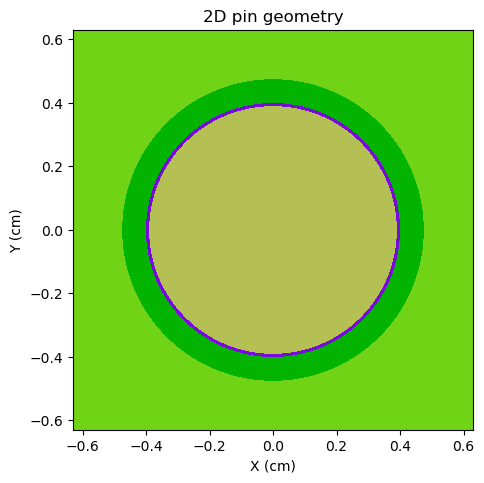

In [4]:
# Create the plot
fig = geometry.plot(basis='xy', origin=(0, 0, 0), width=(pitch, pitch), pixels=(400, 400), color_by='material')

# Set custom x and y labels
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('2D pin geometry')
plt.savefig("geometry.pdf", format = "pdf", dpi = 300, bbox_inches= "tight")
plt.show()

# 3. Settings

In [5]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 100
settings.inactive = 10
settings.particles = 500

settings.export_to_xml()

# 5. Run

In [6]:
# Run the simulation and create statepoint file
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Burnup

In [7]:
import openmc.deplete

In [8]:
chain = openmc.deplete.Chain.from_xml("./chain_casl_pwr.xml")

model = openmc.Model(geometry=geometry, settings=settings)
operator = openmc.deplete.CoupledOperator(model, "./chain_casl_pwr.xml")

P = 170 # W/cm

time_step = [0.5, 0.5, 2, 2, 30, 30, 55] # 4 months

integrator = openmc.deplete.PredictorIntegrator(operator, time_step, P, timestep_units='d')

integrator.integrate()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Mo96 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Mo96.h5
 Reading Mo97 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Mo97.h5
 Reading Mo98 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Mo98.h5
 Reading Mo99 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Mo99.h5
 Reading Mo100 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Mo100.h5
 Reading Tc99 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Tc99.h5


          1200K
          2500K


 Reading Ru100 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru100.h5
 Reading Ru101 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru101.h5
 Reading Ru102 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru102.h5
 Reading Ru103 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru103.h5
 Reading Ru104 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru104.h5
 Reading Ru105 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru105.h5
 Reading Ru106 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Ru106.h5
 Reading Rh102 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Rh102.h5
 Reading Rh103 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Rh103.h5
 Reading Rh104 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Rh104.h5
 Reading Rh105 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Rh105.h5
 Reading Pd104 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pd104.h5
 Reading Pd105 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pd105.h5
 Reading Pd106 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pd106.h5
 Readi

          1200K
          2500K


...

 Reading Pm147 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pm147.h5
 Reading Pm148 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pm148.h5
 Reading Pm148_m1 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pm148_m1.h5
 Reading Pm149 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pm149.h5
 Reading Pm151 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pm151.h5


          250K
          294K
          600K
          900K
          1200K
          2500K


 Reading Sm147 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm147.h5
 Reading Sm148 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm148.h5
 Reading Sm149 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm149.h5
 Reading Sm150 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm150.h5
 Reading Sm151 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm151.h5
 Reading Sm152 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm152.h5
 Reading Sm153 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm153.h5
 Reading Sm154 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Sm154.h5
 Reading Eu151 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu151.h5
 Reading Eu152 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu152.h5
 Reading Eu152_m1 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu152_m1.h5
 Reading Eu153 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu153.h5
 Reading Eu154 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu154.h5
 Reading Eu155 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Eu155.h5


          1200K


 Reading Pu240 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pu240.h5
 Reading Pu241 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pu241.h5
 Reading Pu242 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pu242.h5
 Reading Pu243 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Pu243.h5
 Reading Am241 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am241.h5
 Reading Am242 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am242.h5
 Reading Am242_m1 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am242_m1.h5
 Reading Am243 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am243.h5
 Reading Am244 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am244.h5
 Reading Am244_m1 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Am244_m1.h5
 Reading Cm242 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Cm242.h5
 Reading Cm243 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Cm243.h5
 Reading Cm244 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Cm244.h5
 Reading Cm245 from /home/renato/Desktop/xsdata/jeff-3.3-hdf5/Cm2

# Reading the output

In [9]:
results = openmc.deplete.Results("./depletion_results.h5")
time, k = results.get_keff()
time_days = time / (60 * 60 * 24) # time vector in days

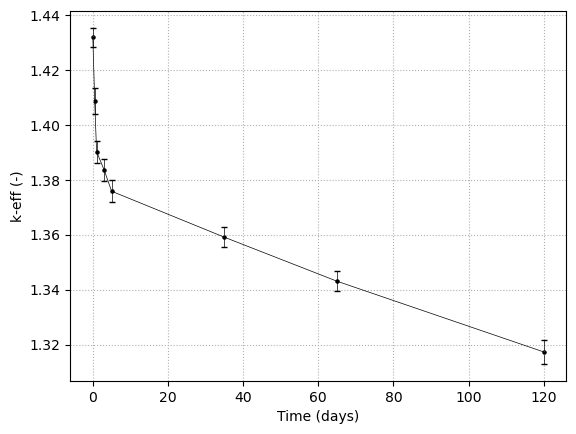

In [10]:
# plot keff
plt.errorbar(time_days, k[:,0], k[:,1], color = "black", linestyle = '-', capsize = 2, linewidth = 0.5)
plt.scatter(time_days, k[:,0], s = 5, color = "black")
plt.xlabel("Time (days)")
plt.ylabel("k-eff (-)")
plt.grid(linestyle = ':')
plt.savefig("./k_time.pdf", format = "pdf", dpi = 500, bbox_inches = "tight")

In [11]:
# read concentrations in time

time, Xe135 = results.get_mass("1", "Xe135") # (g)
time, Sm149 = results.get_mass("1", "Sm149") # (g)

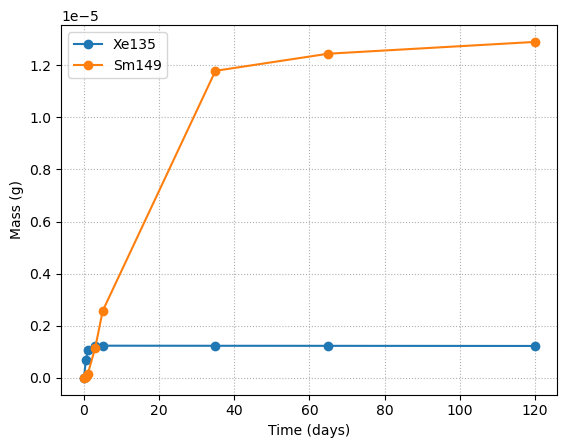

In [12]:
# Plot nuclides in time
plt.plot(time_days, Xe135, '-o', label = "Xe135")
plt.plot(time_days, Sm149, '-o', label = "Sm149")
plt.xlabel("Time (days)")
plt.ylabel("Mass (g)")
plt.legend()
plt.grid(linestyle = ':')
plt.savefig("./poisons.pdf", format = "pdf", dpi = 500, bbox_inches = "tight")